Implementation of Magic Square Game for different boxes of the square

We define the function that gives us the ZX diagram for any of the rows and columns:

In [25]:
import pyzx as zx
import matplotlib.pyplot as plt
from fractions import Fraction
import numpy as np
from pyzx.simplify import *

def create_base_circuit():
    c = zx.Circuit(4)
    c.add_gate("H", 0)
    c.add_gate("H", 1)
    c.add_gate("CNOT", 0, 2)
    c.add_gate("CNOT", 1, 3)
    return c

def generate_circuit_graph(row, col):

    c = create_base_circuit()
    
    if col == 0:
        c.add_gate("H", 2)

    if row == 1:
        c.add_gate("H", 0)
        c.add_gate("H", 1)
        
    if col == 1:
        c.add_gate("H", 3)
        
    if row == 2:
        c.add_gate("CZ", 0, 1)
        c.add_gate("H", 0)
        c.add_gate("H", 1)
        c.add_gate("NOT", 0)
        c.add_gate("NOT", 1)

    if col == 2:
        c.add_gate("CNOT", 2, 3)
        c.add_gate("H", 2)
        
    if col >2 or row >2:
        raise ValueError(f"Circuito no definido para Row {row} - Column {col}")
    
    graph = c.to_graph()

    entradas = graph.inputs()

    for i in range(4):
        graph.set_type(entradas[i], zx.VertexType.X)

    return graph

Row 0 and column 0


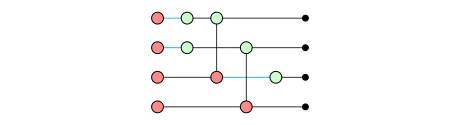

Row 0 and column 1


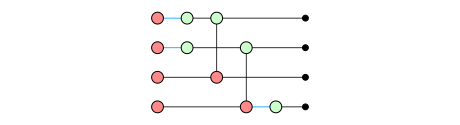

Row 0 and column 2


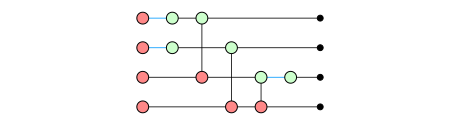

Row 1 and column 0


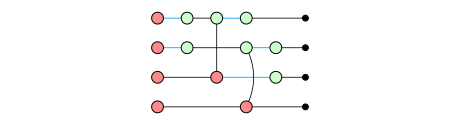

Row 1 and column 1


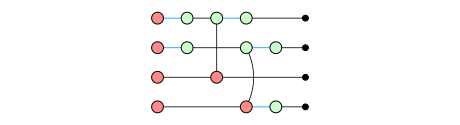

Row 1 and column 2


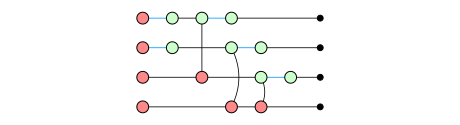

Row 2 and column 0


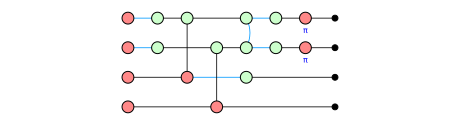

Row 2 and column 1


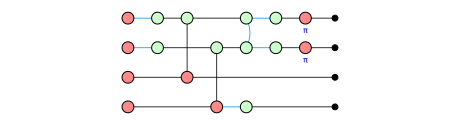

Row 2 and column 2


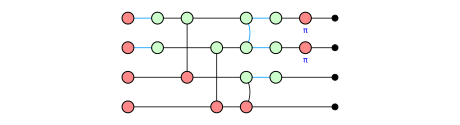

In [16]:
values = [0, 1, 2]

for row in values:
    for column in values:
        print(f"Row {row} and column {column}")
        fig = zx.draw_matplotlib(generate_circuit_graph(row, column))
        display(fig)
        plt.close(fig)

We add measurement projections and verify that the diagram collapse to a null diagram

i1


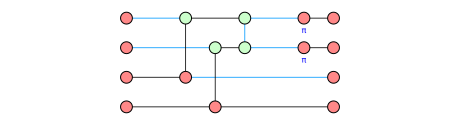

i2


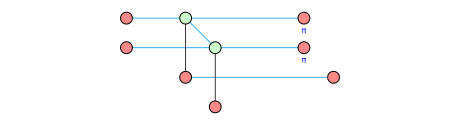

i1


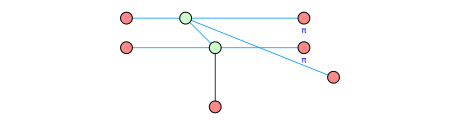

i8


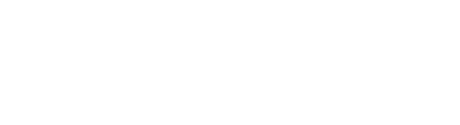

In [26]:
graph = generate_circuit_graph(2, 0)

salidas = graph.outputs()

for i in range(4):
    graph.set_type(salidas[i], zx.VertexType.X)

zx.draw(graph)

opt_graph = graph

while True:
    i1 = id_simp(opt_graph)
    if i1: 
                    fig = zx.draw_matplotlib(opt_graph)
                    print("i1")
                    display(fig)
                    plt.close(fig)
    i2 = spider_simp(opt_graph)
    if i2:         
                    fig = zx.draw_matplotlib(opt_graph)
                    print("i2")
                    display(fig)
                    plt.close(fig)
    i3 = pivot_simp(opt_graph)
    if i3:           
                    fig = zx.draw_matplotlib(opt_graph)
                    print("i1")
                    display(fig)
                    plt.close(fig)
    if not (i1 or i2 or i3): break

while True:
    i4 = lcomp_simp(opt_graph)
    if i4: 
                fig = zx.draw_matplotlib(opt_graph)
                print("i4")
                display(fig)
                plt.close(fig)
    i5 = pivot_boundary_simp(opt_graph)
    if i5: 
                fig = zx.draw_matplotlib(opt_graph)
                print("i5")
                display(fig)
                plt.close(fig)
    i6 = gadget_simp(opt_graph)
    if i6:
                fig = zx.draw_matplotlib(opt_graph)
                print("i6")
                display(fig)
                plt.close(fig)
    i7 = pivot_gadget_simp(opt_graph)
    if i7:
                fig = zx.draw_matplotlib(opt_graph)
                print("i7")
                display(fig)
                plt.close(fig)
            
    i8 = clifford_simp(opt_graph)
    if i8:
                fig = zx.draw_matplotlib(opt_graph)
                print("i8")
                display(fig)
                plt.close(fig)
    if not (i4 or i5 or i6 or i7 or i8): break

We calculate the amplitude of the null diagrams resulting from simplification and use it to validate the deterministically winning strategy

In [10]:
import itertools

measures = [(0, 0), (0, 1), (1, 0), (1, 1)]
values = [0, 1, 2] # Filas y columnas (0, 1, 2)

def scalar_amplitude(row, col, a1, a2, b1, b2):

    graph = generate_circuit_graph(row, col)
    salidas = graph.outputs()

    graph.set_type(salidas[0], zx.VertexType.X)
    graph.set_phase(salidas[0], Fraction(a1, 1))
    graph.set_type(salidas[1], zx.VertexType.X)
    graph.set_phase(salidas[1], Fraction(a2, 1))
    graph.set_type(salidas[2], zx.VertexType.X)
    graph.set_phase(salidas[2], Fraction(b1, 1))
    graph.set_type(salidas[3], zx.VertexType.X)
    graph.set_phase(salidas[3], Fraction(b2, 1))

    zx.simplify.full_reduce(graph)
    return graph.scalar.to_number()

for row, col in itertools.product(values, repeat=2):
    prob_vic1 = 0.0
    prob_der1 = 0.0
    
    # Iteramos por todas las combinaciones posibles de resultados para Alice y Bob
    for (a1, a2), (b1, b2) in itertools.product(measures, repeat=2):
        
        if row == 0:
            # Observables de Fila 0: [I⊗Z (a2), Z⊗I (a1), Z⊗Z (a1^a2)]
            alice_ans = a2 if col == 0 else (a1 if col == 1 else a1 ^ a2)
        elif row == 1:
            # Observables de Fila 1: [X⊗I (a1), I⊗X (a2), X⊗X (a1^a2)]
            alice_ans = a1 if col == 0 else (a2 if col == 1 else a1 ^ a2)
        else: # row == 2
            # Observables de Fila 2: [-X⊗Z (a1), -Z⊗X (a2), Y⊗Y (a1^a2)]
            alice_ans = a1 if col == 0 else (a2 if col == 1 else a1 ^ a2)
            
        # 2. ¿Cuál es la respuesta de Bob para la celda de intersección (row, col)?
        if col == 0:
            # Observables de Col 0: [I⊗Z (b2), X⊗I (b1), -X⊗Z (b1^b2^1)]
            bob_ans = b2 if row == 0 else (b1 if row == 1 else b1 ^ b2 ^ 1)
        elif col == 1:
            # Observables de Col 1: [Z⊗I (b1), I⊗X (b2), -Z⊗X (b1^b2^1)]
            bob_ans = b1 if row == 0 else (b2 if row == 1 else b1 ^ b2 ^ 1)
        else: # col == 2
            # Observables de Col 2: [Z⊗Z (b2), X⊗X (b1), Y⊗Y (b1^b2^1)]
            # (El CNOT hace que b1 mida X⊗X y b2 mida Z⊗Z)
            bob_ans = b2 if row == 0 else (b1 if row == 1 else b1 ^ b2 ^ 1)
        
        # 3. Calculamos la amplitud del circuito para estos resultados
        amp = scalar_amplitude(row, col, a1, a2, b1, b2)
        
        # La probabilidad cuántica es el módulo al cuadrado de la amplitud
        prob = abs(amp)**2
        
        # 4. Verificamos la condición de victoria: coincidir en la intersección
        if alice_ans == bob_ans:
            prob_vic1 += prob
        else:
            prob_der1 += prob

    prob_vic = prob_vic1 / (prob_vic1 + prob_der1)    
    prob_der = prob_der1 / (prob_vic1 + prob_der1)
    # Mostramos el resultado (redondeado para evitar problemas de coma flotante como 0.9999999)
    print(f"Fila {row} y Columna {col} -> Victoria: {prob_vic:.2%}, Derrota: {prob_der:.2%}")

Fila 0 y Columna 0 -> Victoria: 100.00%, Derrota: 0.00%
Fila 0 y Columna 1 -> Victoria: 100.00%, Derrota: 0.00%
Fila 0 y Columna 2 -> Victoria: 100.00%, Derrota: 0.00%
Fila 1 y Columna 0 -> Victoria: 100.00%, Derrota: 0.00%
Fila 1 y Columna 1 -> Victoria: 100.00%, Derrota: 0.00%
Fila 1 y Columna 2 -> Victoria: 100.00%, Derrota: 0.00%
Fila 2 y Columna 0 -> Victoria: 100.00%, Derrota: 0.00%
Fila 2 y Columna 1 -> Victoria: 100.00%, Derrota: 0.00%
Fila 2 y Columna 2 -> Victoria: 100.00%, Derrota: 0.00%


We define a function that yields us the diagram for the Mermin-Peres game with 2DNN connectivity

In [29]:
def local_base_circuit():
    c = zx.Circuit(4)
    c.add_gate("H", 0)
    c.add_gate("H", 2)
    c.add_gate("CNOT", 0, 1)
    c.add_gate("CNOT", 2, 3)
    c.add_gate("SWAP", 1, 2)
    return c

def local_circuit_graph(row, col):

    c = local_base_circuit()
    
    if col == 0:
        c.add_gate("H", 2)

    if row == 1:
        c.add_gate("H", 0)
        c.add_gate("H", 1)
        
    if col == 1:
        c.add_gate("H", 3)
        
    if row == 2:
        c.add_gate("CZ", 0, 1)
        c.add_gate("H", 0)
        c.add_gate("H", 1)
        c.add_gate("NOT", 0)
        c.add_gate("NOT", 1)

    if col == 2:
        c.add_gate("CNOT", 2, 3)
        c.add_gate("H", 2)
        
    if col >2 or row >2:
        raise ValueError(f"Circuito no definido para Row {row} - Column {col}")
    
    graph = c.to_graph()

    entradas = graph.inputs()

    for i in range(4):
        graph.set_type(entradas[i], zx.VertexType.X)

    return graph
for row, col in itertools.product(values, repeat=2):
    print(f"Row {row} and column {col}")
    zx.draw(local_circuit_graph(row, col))

Row 0 and column 0


Row 0 and column 1


Row 0 and column 2


Row 1 and column 0


Row 1 and column 1


Row 1 and column 2


Row 2 and column 0


Row 2 and column 1


Row 2 and column 2


Row 0 and column 0
i1


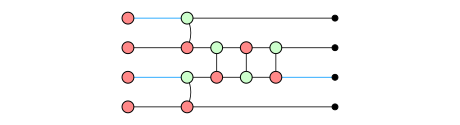

i2


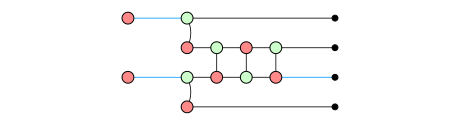

i1


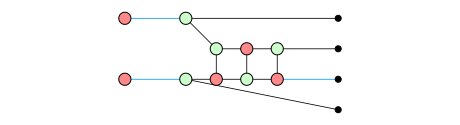

i2


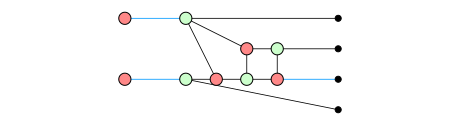

i8


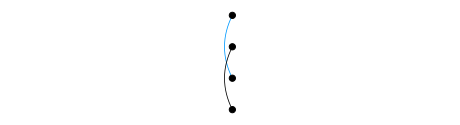

Row 0 and column 1
i1


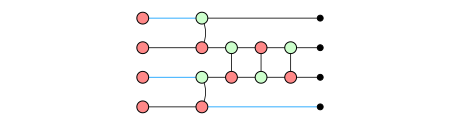

i2


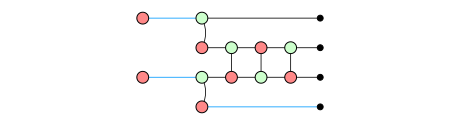

i1


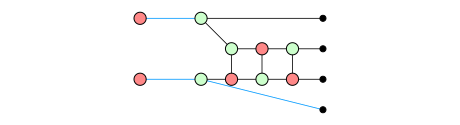

i2


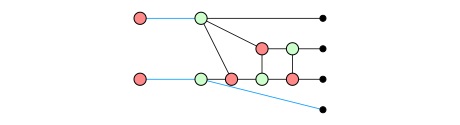

i8


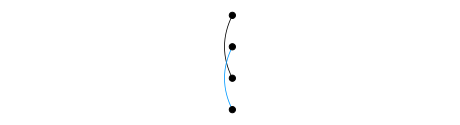

Row 0 and column 2
i1


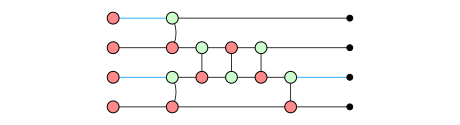

i2


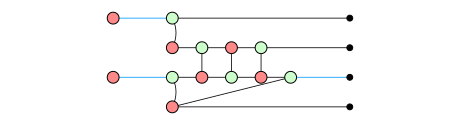

i1


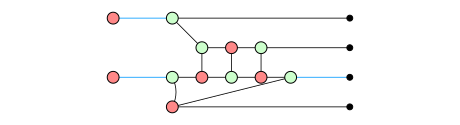

i2


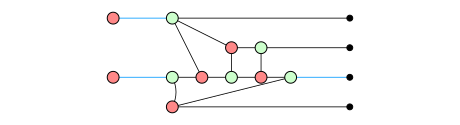

i8


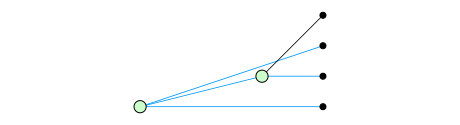

Row 1 and column 0
i1


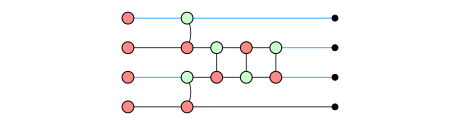

i2


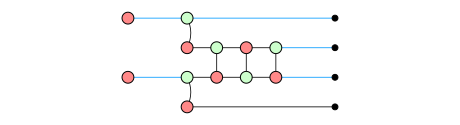

i1


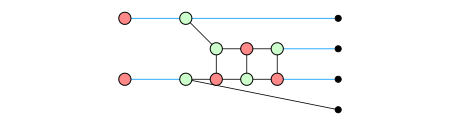

i2


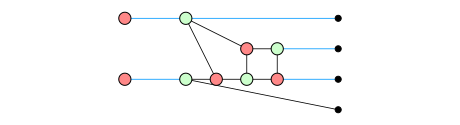

i8


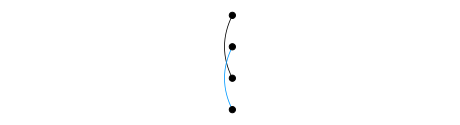

Row 1 and column 1
i1


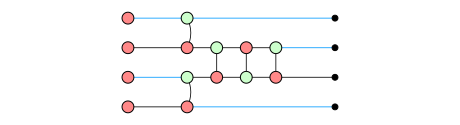

i2


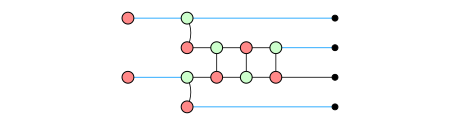

i1


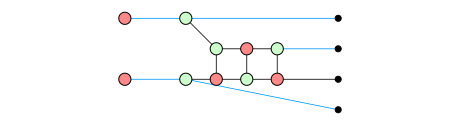

i2


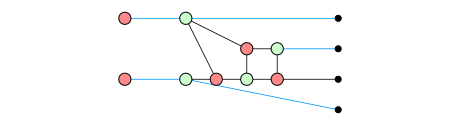

i8


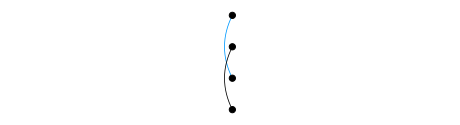

Row 1 and column 2
i1


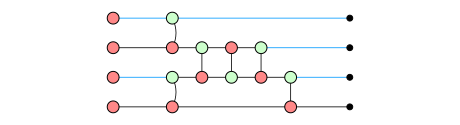

i2


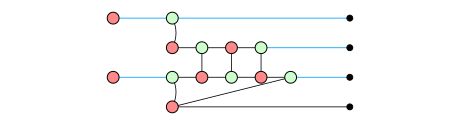

i1


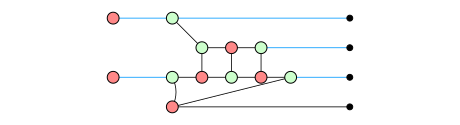

i2


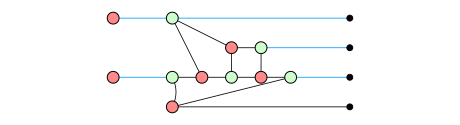

i8


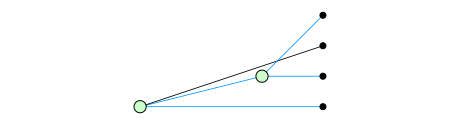

Row 2 and column 0
i1


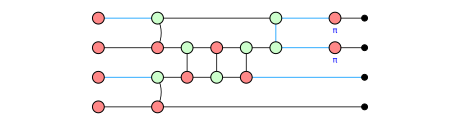

i2


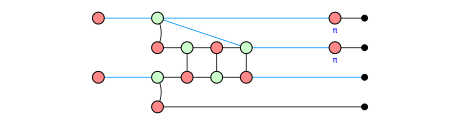

i1


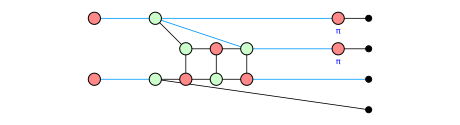

i2


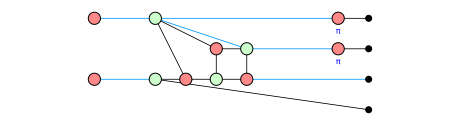

i8


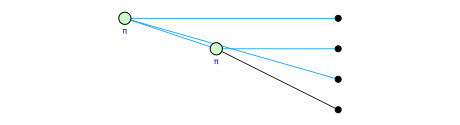

Row 2 and column 1
i1


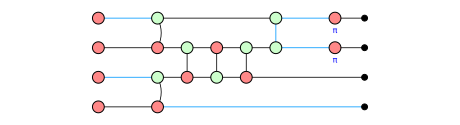

i2


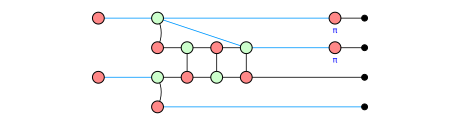

i1


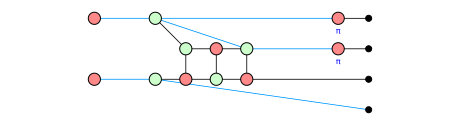

i2


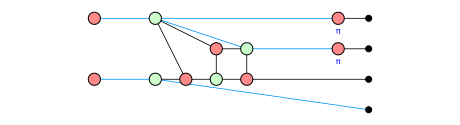

i8


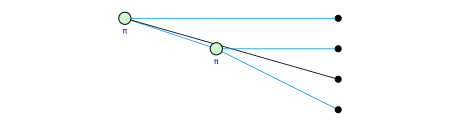

Row 2 and column 2
i1


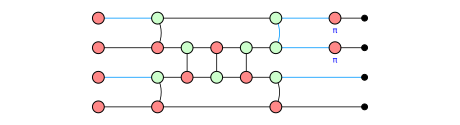

i2


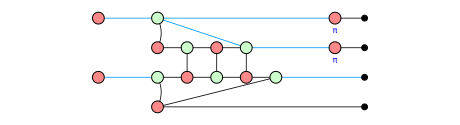

i1


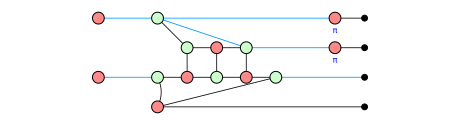

i2


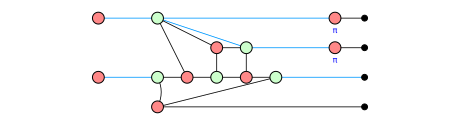

i8


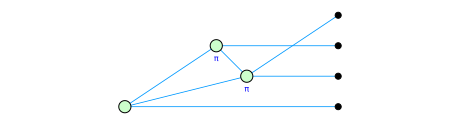

In [23]:
for row, col in itertools.product(values, repeat=2):
    print(f"Row {row} and column {col}")
    opt_graph = local_circuit_graph(row, col)
    while True:
        i1 = id_simp(opt_graph)
        if i1: 
                        fig = zx.draw_matplotlib(opt_graph)
                        print("i1")
                        display(fig)
                        plt.close(fig)
        i2 = spider_simp(opt_graph)
        if i2:         
                        fig = zx.draw_matplotlib(opt_graph)
                        print("i2")
                        display(fig)
                        plt.close(fig)
        i3 = pivot_simp(opt_graph)
        if i3:           
                        fig = zx.draw_matplotlib(opt_graph)
                        print("i1")
                        display(fig)
                        plt.close(fig)
        if not (i1 or i2 or i3): break

    while True:
        i4 = lcomp_simp(opt_graph)
        if i4: 
                    fig = zx.draw_matplotlib(opt_graph)
                    print("i4")
                    display(fig)
                    plt.close(fig)
        i5 = pivot_boundary_simp(opt_graph)
        if i5: 
                    fig = zx.draw_matplotlib(opt_graph)
                    print("i5")
                    display(fig)
                    plt.close(fig)
        i6 = gadget_simp(opt_graph)
        if i6:
                    fig = zx.draw_matplotlib(opt_graph)
                    print("i6")
                    display(fig)
                    plt.close(fig)
        i7 = pivot_gadget_simp(opt_graph)
        if i7:
                    fig = zx.draw_matplotlib(opt_graph)
                    print("i7")
                    display(fig)
                    plt.close(fig)
                
        i8 = clifford_simp(opt_graph)
        if i8:
                    fig = zx.draw_matplotlib(opt_graph)
                    print("i8")
                    display(fig)
                    plt.close(fig)
        if not (i4 or i5 or i6 or i7 or i8): break